# Merge IF cell distance distribution

How deep do double positive cells penetrate tumor?
...actually, why don't we just calculate the distance for all cells. double-label threshold can be determined later 

In [52]:
import os
import tqdm
import anndata as ad
import numpy as np
import pandas as pd

from scipy.spatial import ConvexHull, convex_hull_plot_2d
import shapely as shp
import geopandas as gpd

import matplotlib.pyplot as plt

In [3]:
dat = ad.read_h5ad("../../processed/seurat/integrated_dat_cellPred2.h5ad")
dat

AnnData object with n_obs × n_vars = 27887 × 19311
    obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mt', 'percent.rps', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'integrated_snn_res.0.5', 'var1', 'CD40', 'CD40_asin', 'CD8', 'CD8_asin', 'merge_IF', 'merge_IF_norm', 'sample.id', 'pred.ct.seu.hbca1', 'pred.ct.seu.hbca2', 'pred.ct.SingleR.hbca1', 'pred.ct.SingleR.hbca2', 'pred.ct.SingleR.mouse'
    var: 'features'
    obsm: 'X_umap'

In [15]:
snames = dat.obs['sample.id'].unique()
snames

array(['A1_HE', 'A12_HE', 'A13_HE', 'A14_HE', 'A2_HE', 'A3_HE', 'A30_HE',
       'A31_HE', 'A33_HE', 'A35_HE', 'A4_HE', 'A53_HE', 'A55_HE',
       'A56_HE', 'A63_HE', 'A61_HE', 'A66_HE', 'A64_HE'], dtype=object)

In [70]:
dis = []
for s in tqdm.tqdm(snames):
    s_coords = pd.read_csv("../02-img_registration/data/coordinates/"+s+".csv", index_col=0)
    s_coords = s_coords.loc[s_coords.index.isin(dat.obs_names),:]
    # coords = s_coords[["imagerow","imagecol"]].to_numpy()
    coords = s_coords[["imagecol","imagerow"]].to_numpy()
    # coords = gpd.points_from_xy(x=s_coords.imagecol, y=s_coords.imagerow)
    tissue_hull = ConvexHull(coords)
    # tissue_geom = np.flip(tissue_hull.points[tissue_hull.vertices], 1)
    tissue_geom = tissue_hull.points[tissue_hull.vertices]
    tisse_poly = shp.Polygon(tissue_geom)
    center_dist = np.apply_along_axis(lambda x: tisse_poly.centroid.distance(shp.Point(x)), 1, coords)
    dis.append(pd.Series(center_dist, index = s_coords.index))

100%|██████████| 18/18 [00:02<00:00,  8.65it/s]


In [71]:
all_dis = pd.concat(dis)
all_dis.name = "center_dist"

In [72]:
meta = dat.obs
meta = pd.merge(meta, all_dis, left_index=True, right_index=True)
meta.shape

(27886, 24)

In [73]:
meta.to_csv("new_meta.csv")

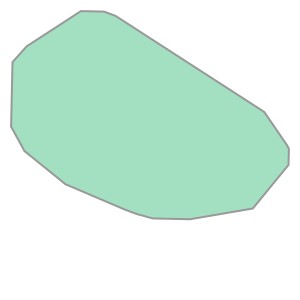

In [74]:
s='A56_HE'
s_coords = pd.read_csv("../02-img_registration/data/coordinates/"+s+".csv", index_col=0)
s_coords = s_coords.loc[s_coords.index.isin(dat.obs_names),:]
# coords = s_coords[["imagerow","imagecol"]].to_numpy()
coords = s_coords[["imagecol","imagerow"]].to_numpy()
# coords = gpd.points_from_xy(x=coords[:,0], y=coords[:,1])
tissue_hull = ConvexHull(coords)
# tissue_geom = np.flip(tissue_hull.points[tissue_hull.vertices], 1)
tissue_geom = tissue_hull.points[tissue_hull.vertices]
tisse_poly = shp.Polygon(tissue_geom)
tisse_poly

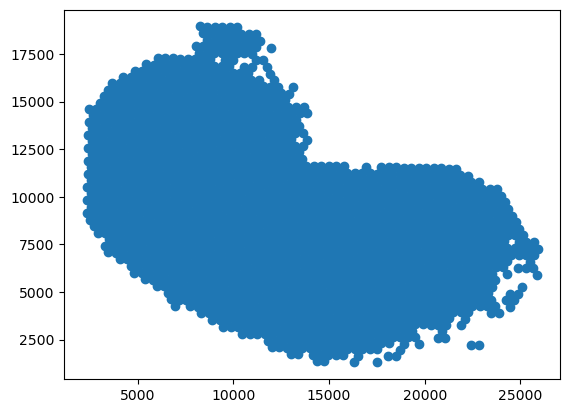

In [75]:
plt.scatter(coords[:,0], coords[:,1])

In [69]:
coords[0:5]

array([[11171, 19832],
       [ 5248, 19861],
       [ 8991, 18125],
       [ 6831, 20540],
       [ 3278, 20557]])

In [32]:
tissue_geom[0:5]

array([[14618.,  2459.],
       [ 9148.,  2341.],
       [ 8455.,  2719.],
       [ 7071.,  3476.],
       [ 4259.,  6954.]])

In [34]:
np.flip(tissue_hull.points[0:5], 1)

array([[ 6453., 16240.],
       [ 5888., 10724.],
       [ 5213., 10316.],
       [14593.,  3638.],
       [ 9390., 22791.]])